In [ ]:
# numpy and pandas will be used for data manipulation
import numpy as np
import pandas as pd

# matplotlib will be used for visually representing our data
import matplotlib.pyplot as plt

# yfinance will be used for importing historical oil prices
import yfinance as yfin

# Setting our ticker
#Task A Question a
ticker = "AMZN"
ticker = yfin.Ticker(ticker)

# Importing our data
# The period is set to "5y", which retrieves the last five years of daily price data
data = ticker.history(period="5y")

data

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2021-01-07 00:00:00-05:00,157.850006,160.427002,157.750000,158.108002,70290000,0.0,0.0
2021-01-08 00:00:00-05:00,159.000000,159.531998,157.110001,159.134995,70754000,0.0,0.0
2021-01-11 00:00:00-05:00,157.400497,157.819000,155.500000,155.710495,73668000,0.0,0.0
2021-01-12 00:00:00-05:00,156.000000,157.106995,154.300003,156.041504,70292000,0.0,0.0
2021-01-13 00:00:00-05:00,156.421997,159.497498,156.104004,158.294495,66424000,0.0,0.0
...,...,...,...,...,...,...,...
2025-12-31 00:00:00-05:00,232.910004,232.990005,230.119995,230.820007,24383700,0.0,0.0
2026-01-02 00:00:00-05:00,231.339996,235.460007,224.699997,226.500000,51456200,0.0,0.0
2026-01-05 00:00:00-05:00,228.839996,234.000000,227.179993,233.059998,49733300,0.0,0.0


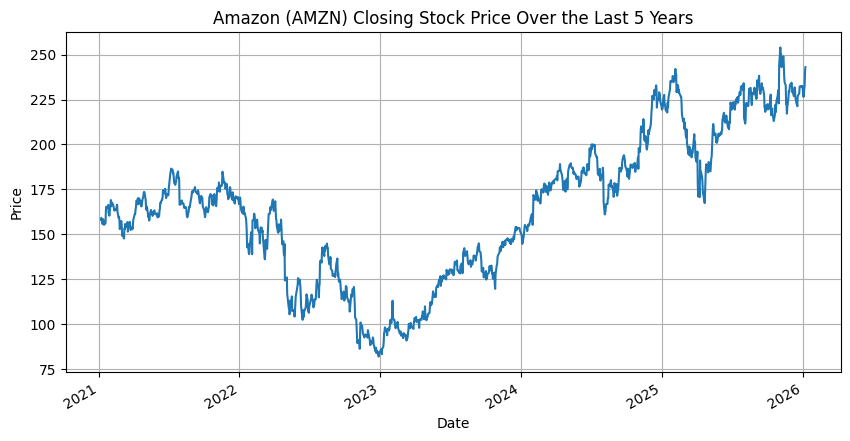

In [ ]:
# Plotting the closing price of Amazon (AMZN) for the last 5 years
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

data['Close'].plot()

# Adding required labels and title
plt.title("Amazon (AMZN) Closing Stock Price Over the Last 5 Years")
plt.xlabel("Date")
plt.ylabel("Price")

# Adding a grid for better readability
plt.grid(True)

plt.show()

# Commentary on AMZN stock price over the last 5 years:
# - Overall trend: The stock shows a general upward trend over the 5-year period.
# - Volatility: There are noticeable fluctuations, with some sharp drops and recoveries, reflecting market volatility.
# - Peaks and troughs: The stock reached significant highs around late 2023 and experienced notable dips around early 2022.

In [ ]:
#Task A Question b
data['SMA_20'] = data['Close'].rolling(window=20).mean()
data['SMA_50'] = data['Close'].rolling(window=50).mean()

data['EMA_20'] = data['Close'].ewm(span=20, adjust=False).mean()

delta = data['Close'].diff(1)
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()
rs = avg_gain / avg_loss
data['RSI'] = 100 - (100 / (1 + rs))

data

,Open,High,Low,Close,Volume,Dividends,Stock Splits,SMA_20,SMA_50,EMA_20,RSI
Date,,,,,,,,,,,
2021-01-07 00:00:00-05:00,157.850006,160.427002,157.750000,158.108002,70290000,0.0,0.0,NaN,NaN,158.108002,NaN
2021-01-08 00:00:00-05:00,159.000000,159.531998,157.110001,159.134995,70754000,0.0,0.0,NaN,NaN,158.205811,NaN
2021-01-11 00:00:00-05:00,157.400497,157.819000,155.500000,155.710495,73668000,0.0,0.0,NaN,NaN,157.968161,NaN
2021-01-12 00:00:00-05:00,156.000000,157.106995,154.300003,156.041504,70292000,0.0,0.0,NaN,NaN,157.784670,NaN
2021-01-13 00:00:00-05:00,156.421997,159.497498,156.104004,158.294495,66424000,0.0,0.0,NaN,NaN,157.833225,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 00:00:00-05:00,232.910004,232.990005,230.119995,230.820007,24383700,0.0,0.0,228.772501,231.436801,229.774434,48.034414
2026-01-02 00:00:00-05:00,231.339996,235.460007,224.699997,226.500000,51456200,0.0,0.0,228.478500,231.526201,229.462584,43.061674
2026-01-05 00:00:00-05:00,228.839996,234.000000,227.179993,233.059998,49733300,0.0,0.0,228.676000,231.828401,229.805194,61.561759


In [ ]:
data = data.dropna()

In [ ]:
data

,Open,High,Low,Close,Volume,Dividends,Stock Splits,SMA_20,SMA_50,EMA_20,RSI
Date,,,,,,,,,,,
2021-03-19 00:00:00-04:00,151.461502,153.864502,150.831497,153.748001,92508000,0.0,0.0,153.990752,159.182340,155.042310,44.547255
2021-03-22 00:00:00-04:00,153.392502,156.328995,153.002502,155.543503,58044000,0.0,0.0,153.816077,159.131050,155.090043,51.282577
2021-03-23 00:00:00-04:00,156.350006,159.100006,156.042496,156.875000,76346000,0.0,0.0,153.673576,159.085850,155.260039,61.539807
2021-03-24 00:00:00-04:00,157.552002,158.015503,154.257507,154.353500,59180000,0.0,0.0,153.492426,159.058710,155.173702,59.169335
2021-03-25 00:00:00-04:00,153.649506,155.488998,151.856995,152.313004,71270000,0.0,0.0,153.465176,158.984140,154.901254,53.723473
...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 00:00:00-05:00,232.910004,232.990005,230.119995,230.820007,24383700,0.0,0.0,228.772501,231.436801,229.774434,48.034414
2026-01-02 00:00:00-05:00,231.339996,235.460007,224.699997,226.500000,51456200,0.0,0.0,228.478500,231.526201,229.462584,43.061674
2026-01-05 00:00:00-05:00,228.839996,234.000000,227.179993,233.059998,49733300,0.0,0.0,228.676000,231.828401,229.805194,61.561759


In [ ]:
# Initialising X and assigning the four feature variables
X = data[['EMA_20','SMA_50']]

# Getting the head of the data
X.head()

,EMA_20,SMA_50
Date,,
2021-03-19 00:00:00-04:00,155.042310,159.18234
2021-03-22 00:00:00-04:00,155.090043,159.13105
2021-03-23 00:00:00-04:00,155.260039,159.08585
2021-03-24 00:00:00-04:00,155.173702,159.05871
2021-03-25 00:00:00-04:00,154.901254,158.98414


In [ ]:
# Setting-up the dependent variable
y = data['Close']

# Getting the head of the data
y.head()

,Close
Date,
2021-03-19 00:00:00-04:00,153.748001
2021-03-22 00:00:00-04:00,155.543503
2021-03-23 00:00:00-04:00,156.875000
2021-03-24 00:00:00-04:00,154.353500
2021-03-25 00:00:00-04:00,152.313004


In [ ]:
#Task A Question c

#Setting Reproducible Seed (We use a Reproducible Seed for reproducibility, not needed for sequential split.)
seed = 48
# Setting the training set to 70% of the data
training = 0.7
t = int(training*len(data))

# Training dataset
X_train = X[:t]
y_train = y[:t]

# Testing dataset
X_test = X[t:]
y_test = y[t:]

In [ ]:
X[:t]


,EMA_20,SMA_50
Date,,
2021-03-19 00:00:00-04:00,155.042310,159.182340
2021-03-22 00:00:00-04:00,155.090043,159.131050
2021-03-23 00:00:00-04:00,155.260039,159.085850
2021-03-24 00:00:00-04:00,155.173702,159.058710
2021-03-25 00:00:00-04:00,154.901254,158.984140
...,...,...
2024-07-22 00:00:00-04:00,190.337445,187.558800
2024-07-23 00:00:00-04:00,189.963403,187.497000
2024-07-24 00:00:00-04:00,189.093555,187.364001


In [ ]:
#Task A Question d
from sklearn.linear_model import LinearRegression

# Handle NaN values by dropping rows where X_train has NaNs
X_train_cleaned = X_train.dropna()
# Ensure y_train aligns with cleaned X_train
y_train_cleaned = y_train[X_train_cleaned.index]

model = LinearRegression().fit(X_train_cleaned,y_train_cleaned)
print("Linear Regression Model Defined and Trained")

Linear Regression Model Defined and Trained


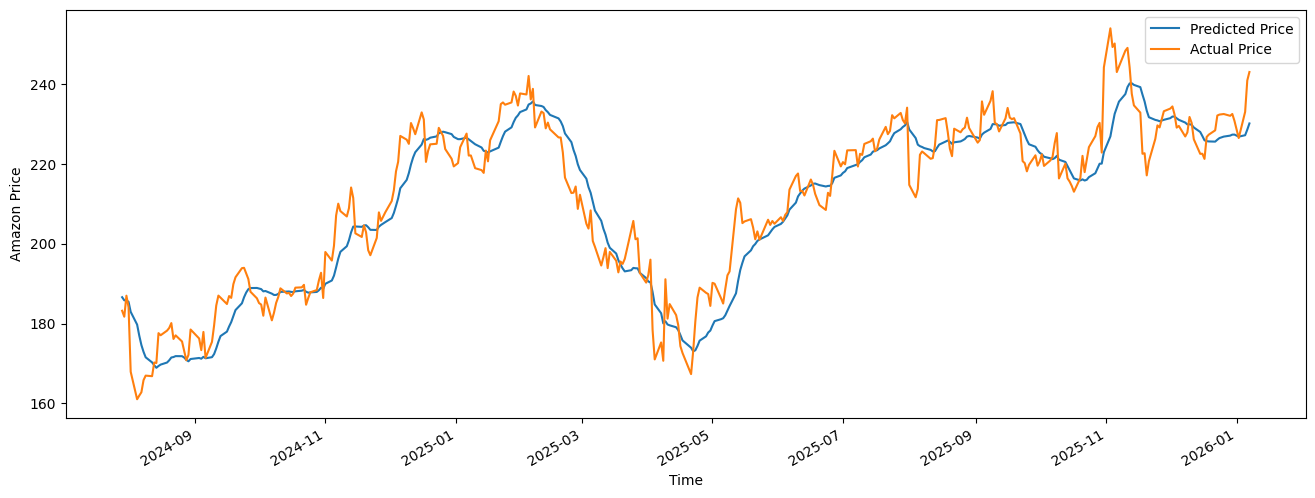

In [ ]:
#Task A Question e
predicted_price = model.predict(X_test)
predicted_price = pd.DataFrame(predicted_price, index=y_test.index, columns=['Close'])
predicted_price.plot(figsize=(16,6))
y_test.plot()

plt.legend(['Predicted Price', 'Actual Price'])
plt.xlabel('Time')
plt.ylabel('Amazon Price')
plt.show()

In [ ]:
R_squared_score = model.score(X_test.dropna(), y_test[X_test.dropna().index]) * 100
accuracy = "{0:.2f}".format(R_squared_score)
print("The model has a " + accuracy + "% accuracy.")

The model has a 89.60% accuracy.


In [ ]:
#Task A Question f
print(f'alpha = {model.intercept_}')
print(f'betas = {model.coef_}')
print(f"Predicted Price = {model.intercept_} + ({model.coef_[0]} * EMA_20) + ({model.coef_[1]} * SMA_50)")


alpha = 2.7299279775985212
betas = [ 1.51557027 -0.53406647]
Predicted Price = 2.7299279775985212 + (1.515570269549142 * EMA_20) + (-0.5340664681777866 * SMA_50)
